# NeuroScope AI - Notebook 10: ONNX Export & Quantization

Benchmarks all 6 pipeline models at FP32, FP16, and INT8 on both GPU and CPU.
Produces quantized INT8 models for Tier 2 (CPU workstation) and Tier 3 (edge) deployment.

**Three deployment tiers:**
- Tier 1 GPU  : FP32/FP16 full precision, ~15-30s per scan
- Tier 2 CPU  : INT8 quantized, ~60-90s per scan on i7/Ryzen
- Tier 3 Edge : INT8 + rule-based fallback, runs on any laptop

**What this notebook does:**
1. Verify all ONNX models are present and valid
2. Benchmark FP32 inference speed (GPU + CPU) per model
3. Apply static INT8 quantization via ONNX Runtime
4. Benchmark INT8 inference speed
5. Compare model size: FP32 vs INT8
6. Validate INT8 accuracy vs FP32 on sample inputs
7. Generate deployment summary table

**Expected results on RTX 4060 + i7:**
| Model        | FP32 GPU | FP32 CPU | INT8 CPU | Size FP32 | Size INT8 |
|---|---|---|---|---|---|
| brain_cls    | <50ms    | ~800ms   | ~200ms   | ~70MB     | ~18MB     |
| breast_det   | <50ms    | ~800ms   | ~200ms   | ~70MB     | ~18MB     |
| skin_cls     | <50ms    | ~800ms   | ~200ms   | ~70MB     | ~18MB     |
| spine        | ~150ms   | ~2.5s    | ~600ms   | ~210MB    | ~53MB     |

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, time, json, warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import torch
import onnx
import onnxruntime as ort
from onnxruntime.quantization import (
    quantize_dynamic, quantize_static,
    QuantType, QuantFormat
)

BASE    = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
MODELS  = os.path.join(BASE, 'models', 'production')
QUANT   = os.path.join(BASE, 'models', 'quantized')
OUT     = os.path.join(BASE, 'outputs', 'nb10_quantization')
os.makedirs(QUANT, exist_ok=True)
os.makedirs(OUT,   exist_ok=True)
sys.path.insert(0, BASE)

GPU_PROVIDERS = ['CUDAExecutionProvider', 'CPUExecutionProvider']
CPU_PROVIDERS = ['CPUExecutionProvider']

print(f'ONNX Runtime : {ort.__version__}')
print(f'ONNX         : {onnx.__version__}')
print(f'PyTorch      : {torch.__version__}')
print(f'CUDA avail   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
print('Imports OK')

ONNX Runtime : 1.26.0
ONNX         : 1.21.0
PyTorch      : 2.5.1+cu121
CUDA avail   : True
GPU          : NVIDIA GeForce RTX 4060 Laptop GPU
Imports OK


---
## Cell 2 - Model Registry

In [7]:
import os
import onnxruntime as ort

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
MODELS = os.path.join(BASE, 'models', 'production')


def get_model_input_spec(onnx_path):
    """Read actual input name and shape directly from the ONNX graph."""
    if not os.path.exists(onnx_path):
        return []
    sess   = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    inputs = []
    for inp in sess.get_inputs():
        shape = [d if isinstance(d, int) and d > 0 else 1
                 for d in inp.shape]
        inputs.append((inp.name, shape))
    return inputs


# Auto-detect input specs from each model
print('Reading input specs from ONNX graphs...')
paths = {
    'brain_cls' : os.path.join(MODELS, 'brain_cls',  'brain_cls_efficientnet.onnx'),
    'brain_seg' : os.path.join(MODELS, 'brain_seg',  'brain_seg_resnet.onnx'),
    'breast_det': os.path.join(MODELS, 'breast_det', 'breast_det_efficientnet.onnx'),
    'liver_seg' : os.path.join(MODELS, 'liver_seg',  'liver_seg_resnet.onnx'),
    'lung_det'  : os.path.join(MODELS, 'lung_det',   'lung_det_resnet3d.onnx'),
    'skin_cls'  : os.path.join(MODELS, 'skin_cls',   'skin_cls_efficientnet.onnx'),
    'spine_cls' : os.path.join(MODELS, 'spine',      'spine_hybridspinenet.onnx'),
}

MODEL_REGISTRY = [
    {
        'name'    : 'brain_cls',
        'path'    : paths['brain_cls'],
        'pipeline': 'brain',
        'task'    : 'classification',
        'inputs'  : get_model_input_spec(paths['brain_cls']),
        'notes'   : 'EfficientNet-B4, 4-class brain tumor type',
    },
    {
        'name'    : 'brain_seg',
        'path'    : paths['brain_seg'],
        'pipeline': 'brain',
        'task'    : 'segmentation',
        'inputs'  : get_model_input_spec(paths['brain_seg']),
        'notes'   : 'SegResNet 3D, BraTS segmentation',
    },
    {
        'name'    : 'breast_det',
        'path'    : paths['breast_det'],
        'pipeline': 'breast',
        'task'    : 'detection',
        'inputs'  : get_model_input_spec(paths['breast_det']),
        'notes'   : 'EfficientNet-B4, binary benign/malignant',
    },
    {
        'name'    : 'liver_seg',
        'path'    : paths['liver_seg'],
        'pipeline': 'liver',
        'task'    : 'segmentation',
        'inputs'  : get_model_input_spec(paths['liver_seg']),
        'notes'   : 'SegResNet, liver/tumor segmentation',
    },
    {
        'name'    : 'lung_det',
        'path'    : paths['lung_det'],
        'pipeline': 'lung',
        'task'    : 'detection',
        'inputs'  : get_model_input_spec(paths['lung_det']),
        'notes'   : '3D CNN, binary nodule detection',
    },
    {
        'name'    : 'skin_cls',
        'path'    : paths['skin_cls'],
        'pipeline': 'skin',
        'task'    : 'classification',
        'inputs'  : get_model_input_spec(paths['skin_cls']),
        'notes'   : 'EfficientNet-B4, 7-class dermoscopy',
    },
    {
        'name'    : 'spine_cls',
        'path'    : paths['spine_cls'],
        'pipeline': 'spine',
        'task'    : 'multi-target classification',
        'inputs'  : get_model_input_spec(paths['spine_cls']),
        'notes'   : 'HybridSpineNet 3-view, 25-target severity',
    },
]

print(f'\nModel registry: {len(MODEL_REGISTRY)} models')
print()
for m in MODEL_REGISTRY:
    exists = os.path.exists(m['path'])
    size   = os.path.getsize(m['path']) / (1024**2) if exists else 0
    status = f'OK ({size:.1f} MB)' if exists else 'MISSING'
    print(f'  {m["name"]:15s}: {status}')
    for inp_name, inp_shape in m['inputs']:
        print(f'    input {inp_name}: {inp_shape}')

Reading input specs from ONNX graphs...

Model registry: 7 models

  brain_cls      : OK (72.0 MB)
    input input: [1, 3, 224, 224]
  brain_seg      : OK (18.0 MB)
    input input: [1, 4, 96, 96, 96]
  breast_det     : OK (70.7 MB)
    input input: [1, 3, 512, 512]
  liver_seg      : OK (24.1 MB)
    input input: [1, 3, 256, 256]
  lung_det       : OK (27.3 MB)
    input patch: [1, 1, 32, 32, 32]
  skin_cls       : OK (71.0 MB)
    input input: [1, 3, 384, 384]
  spine_cls      : OK (273.2 MB)
    input sag_t1: [1, 3, 384, 384]
    input sag_t2: [1, 3, 384, 384]
    input ax_t2: [1, 3, 384, 384]


---
## Cell 3 - ONNX Validation

In [8]:
import onnx, os

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
MODELS = os.path.join(BASE, 'models', 'production')


def validate_onnx(path):
    """Check ONNX model graph is well-formed."""
    if not os.path.exists(path):
        return False, 'File not found'
    try:
        model = onnx.load(path)
        onnx.checker.check_model(model)
        # Collect input/output info
        inputs  = [(i.name, [d.dim_value for d in i.type.tensor_type.shape.dim])
                   for i in model.graph.input]
        outputs = [(o.name, [d.dim_value for d in o.type.tensor_type.shape.dim])
                   for o in model.graph.output]
        n_nodes = len(model.graph.node)
        return True, {'inputs': inputs, 'outputs': outputs, 'nodes': n_nodes}
    except Exception as e:
        return False, str(e)


print('ONNX model validation:')
print('=' * 70)
all_valid = True
for m in MODEL_REGISTRY:
    ok, info = validate_onnx(m['path'])
    if ok:
        print(f'  {m["name"]:15s}: VALID  ({info["nodes"]} nodes)')
        for inp_name, inp_shape in info['inputs']:
            print(f'    input  {inp_name}: {inp_shape}')
        for out_name, out_shape in info['outputs']:
            print(f'    output {out_name}: {out_shape}')
    else:
        print(f'  {m["name"]:15s}: INVALID -- {info}')
        all_valid = False
    print()

print('All valid!' if all_valid else 'Some models need re-export.')

ONNX model validation:
  brain_cls      : VALID  (1048 nodes)
    input  input: [0, 3, 224, 224]
    output type_logits: [0, 4]
    output grade_logits: [0, 4]
    output marker_logits: [0, 3]

  brain_seg      : VALID  (345 nodes)
    input  input: [0, 4, 96, 96, 96]
    output output: [0, 4, 96, 96, 96]

  breast_det     : VALID  (1042 nodes)
    input  input: [0, 3, 512, 512]
    output logit: [0, 1]

  liver_seg      : VALID  (303 nodes)
    input  input: [0, 3, 256, 256]
    output output: [0, 2, 256, 256]

  lung_det       : VALID  (31 nodes)
    input  patch: [0, 1, 32, 32, 32]
    output logits: [0, 2]

  skin_cls       : VALID  (1042 nodes)
    input  input: [0, 3, 384, 384]
    output logits: [0, 7]

  spine_cls      : VALID  (3312 nodes)
    input  sag_t1: [0, 3, 384, 384]
    input  sag_t2: [0, 3, 384, 384]
    input  ax_t2: [0, 3, 384, 384]
    output logits: [0, 25, 3]
    output cauda_logit: [0, 1]

All valid!


---
## Cell 4 - Inference Benchmarking

In [9]:
import os, time, numpy as np
import onnxruntime as ort

BASE          = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
GPU_PROVIDERS = ['CUDAExecutionProvider', 'CPUExecutionProvider']
CPU_PROVIDERS = ['CPUExecutionProvider']
N_WARMUP      = 3
N_RUNS        = 10


def make_dummy_inputs(model_spec):
    """Create random float32 input arrays for a model."""
    return {name: np.random.randn(*shape).astype(np.float32)
            for name, shape in model_spec['inputs']}


def benchmark_model(model_spec, providers, n_warmup=3, n_runs=10):
    """
    Benchmark ONNX model inference speed.
    Returns mean latency in milliseconds.
    """
    path = model_spec['path']
    if not os.path.exists(path):
        return None, 'Model not found'

    try:
        sess   = ort.InferenceSession(path, providers=providers)
        inputs = make_dummy_inputs(model_spec)
        out_names = [o.name for o in sess.get_outputs()]

        # Warmup
        for _ in range(n_warmup):
            sess.run(out_names, inputs)

        # Benchmark
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            sess.run(out_names, inputs)
            times.append((time.perf_counter() - t0) * 1000)  # ms

        return {
            'mean_ms'  : float(np.mean(times)),
            'std_ms'   : float(np.std(times)),
            'min_ms'   : float(np.min(times)),
            'max_ms'   : float(np.max(times)),
            'provider' : sess.get_providers()[0],
        }, None

    except Exception as e:
        return None, str(e)


results = {}
import torch

for m in MODEL_REGISTRY:
    if not os.path.exists(m['path']):
        print(f'  {m["name"]}: SKIPPED (not found)')
        continue

    print(f'Benchmarking {m["name"]}...')
    model_results = {}

    # GPU benchmark
    if torch.cuda.is_available():
        gpu_res, err = benchmark_model(m, GPU_PROVIDERS, N_WARMUP, N_RUNS)
        if gpu_res:
            model_results['gpu_fp32'] = gpu_res
            print(f'  GPU FP32 : {gpu_res["mean_ms"]:7.1f}ms ± {gpu_res["std_ms"]:5.1f}ms '
                  f'(via {gpu_res["provider"]})')
        else:
            print(f'  GPU FP32 : FAILED -- {err}')

    # CPU benchmark
    cpu_res, err = benchmark_model(m, CPU_PROVIDERS, N_WARMUP, N_RUNS)
    if cpu_res:
        model_results['cpu_fp32'] = cpu_res
        print(f'  CPU FP32 : {cpu_res["mean_ms"]:7.1f}ms ± {cpu_res["std_ms"]:5.1f}ms')
    else:
        print(f'  CPU FP32 : FAILED -- {err}')

    results[m['name']] = model_results
    print()

print('FP32 benchmarks complete')

Benchmarking brain_cls...
  GPU FP32 :    11.0ms ±   1.6ms (via CUDAExecutionProvider)
  CPU FP32 :    19.5ms ±   1.3ms

Benchmarking brain_seg...
  GPU FP32 :    52.0ms ±   2.6ms (via CUDAExecutionProvider)
  CPU FP32 :   578.6ms ±  11.2ms

Benchmarking breast_det...
  GPU FP32 :    19.8ms ±   0.6ms (via CUDAExecutionProvider)
  CPU FP32 :   112.3ms ±   4.5ms

Benchmarking liver_seg...
  GPU FP32 :    11.0ms ±   1.7ms (via CUDAExecutionProvider)
  CPU FP32 :   180.1ms ±   5.1ms

Benchmarking lung_det...
  GPU FP32 :     5.5ms ±   0.4ms (via CUDAExecutionProvider)
  CPU FP32 :     9.9ms ±   0.6ms

Benchmarking skin_cls...
  GPU FP32 :    14.6ms ±   2.2ms (via CUDAExecutionProvider)
  CPU FP32 :    42.7ms ±   1.8ms

Benchmarking spine_cls...
  GPU FP32 :    35.5ms ±   3.9ms (via CUDAExecutionProvider)
  CPU FP32 :   132.8ms ±   6.3ms

FP32 benchmarks complete


---
## Cell 5 - Dynamic INT8 Quantization

In [10]:
import os
from onnxruntime.quantization import quantize_dynamic, QuantType

BASE  = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
QUANT = os.path.join(BASE, 'models', 'quantized')
os.makedirs(QUANT, exist_ok=True)


def quantize_model(model_spec):
    """
    Apply dynamic INT8 quantization.

    Dynamic quantization:
    - Weights quantized to INT8 at export time (no calibration data needed)
    - Activations quantized dynamically at runtime
    - 3-4x model size reduction
    - 2-4x CPU speedup
    - Minimal accuracy loss for classification models (<1% typically)
    """
    src  = model_spec['path']
    name = model_spec['name']

    if not os.path.exists(src):
        print(f'  {name}: SKIPPED (source not found)')
        return None

    # Create subfolder per pipeline
    pipeline_dir = os.path.join(QUANT, model_spec['pipeline'])
    os.makedirs(pipeline_dir, exist_ok=True)
    dst = os.path.join(pipeline_dir, f'{name}_int8.onnx')

    try:
        quantize_dynamic(
            model_input  = src,
            model_output = dst,
            weight_type  = QuantType.QInt8,
        )
        src_mb = os.path.getsize(src) / (1024**2)
        dst_mb = os.path.getsize(dst) / (1024**2)
        ratio  = src_mb / dst_mb
        print(f'  {name}: {src_mb:.1f} MB -> {dst_mb:.1f} MB '
              f'({ratio:.1f}x smaller) -> {dst}')
        return dst
    except Exception as e:
        print(f'  {name}: FAILED -- {e}')
        return None


print('Applying dynamic INT8 quantization...')
print()
quant_paths = {}
for m in MODEL_REGISTRY:
    dst = quantize_model(m)
    if dst:
        quant_paths[m['name']] = dst

print(f'\nQuantized {len(quant_paths)}/{len(MODEL_REGISTRY)} models')

Applying dynamic INT8 quantization...



  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
   

  brain_cls: 72.0 MB -> 18.8 MB (3.8x smaller) -> C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\quantized\brain\brain_cls_int8.onnx


  brain_seg: 18.0 MB -> 4.6 MB (3.9x smaller) -> C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\quantized\brain\brain_seg_int8.onnx


  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
   

...

  lung_det: 27.3 MB -> 6.9 MB (4.0x smaller) -> C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\quantized\lung\lung_det_int8.onnx


  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
   

  skin_cls: 71.0 MB -> 18.5 MB (3.8x smaller) -> C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\quantized\skin\skin_cls_int8.onnx


  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_value: 4
    }
    dim {
   

  spine_cls: 273.2 MB -> 70.8 MB (3.9x smaller) -> C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\quantized\spine\spine_cls_int8.onnx

Quantized 7/7 models


---
## Cell 6 - INT8 Benchmark

In [12]:
import os, time, numpy as np
import onnxruntime as ort

BASE          = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
QUANT         = os.path.join(BASE, 'models', 'quantized')
CPU_PROVIDERS = ['CPUExecutionProvider']
N_WARMUP      = 1    # was 3
N_RUNS        = 5    # was 10

if 'quant_paths' not in dir():
    raise RuntimeError('quant_paths not defined -- run Cell 5 first.')

print('Benchmarking INT8 models (CPU only)...')
print()

for m in MODEL_REGISTRY:
    name       = m['name']
    quant_path = quant_paths.get(name)
    if not quant_path or not os.path.exists(quant_path):
        print(f'  {name}: no quantized model')
        continue

    try:
        sess      = ort.InferenceSession(quant_path, providers=CPU_PROVIDERS)
        inputs    = {inp_name: np.random.randn(*shape).astype(np.float32)
                     for inp_name, shape in m['inputs']}
        out_names = [o.name for o in sess.get_outputs()]

        for _ in range(N_WARMUP):
            sess.run(out_names, inputs)

        times = []
        for _ in range(N_RUNS):
            t0 = time.perf_counter()
            sess.run(out_names, inputs)
            times.append((time.perf_counter() - t0) * 1000)

        mean_ms = float(np.mean(times))
        std_ms  = float(np.std(times))

        fp32_ms = results.get(name, {}).get('cpu_fp32', {}).get('mean_ms')
        speedup = f'{fp32_ms/mean_ms:.1f}x faster' if fp32_ms and mean_ms > 0 else 'N/A'

        results[name]['cpu_int8'] = {'mean_ms': mean_ms, 'std_ms': std_ms}
        print(f'  {name:15s}: {mean_ms:7.1f}ms ± {std_ms:5.1f}ms  ({speedup})')

    except Exception as e:
        print(f'  {name}: FAILED -- {e}')

print('\nINT8 benchmarks complete')

Benchmarking INT8 models (CPU only)...

  brain_cls      :   410.9ms ±   7.9ms  (0.0x faster)
  brain_seg      : 33768.2ms ± 2242.8ms  (0.0x faster)
  breast_det     :  2735.7ms ±  33.9ms  (0.0x faster)
  liver_seg      :  2596.5ms ±  37.7ms  (0.1x faster)
  lung_det       :   430.8ms ±   9.3ms  (0.0x faster)
  skin_cls       :   985.9ms ±  17.0ms  (0.0x faster)
  spine_cls      :  3218.0ms ± 221.1ms  (0.0x faster)

INT8 benchmarks complete


---
## Cell 7 - Accuracy Validation (FP32 vs INT8)

In [14]:
import os, numpy as np
import onnxruntime as ort

BASE          = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CPU_PROVIDERS = ['CPUExecutionProvider']
N_SAMPLES     = 10   # was 50

# Skip 3D models -- too slow for CPU comparison
SKIP_3D = {'brain_seg', 'liver_seg'}

print('FP32 vs INT8 accuracy comparison:')
print(f'{"Model":15s} {"Max Diff":12s} {"Top-1 Agreement":16s} {"Assessment":15s}')
print('-' * 60)

for m in MODEL_REGISTRY:
    name       = m['name']
    quant_path = quant_paths.get(name)
    if not quant_path:
        continue

    if name in SKIP_3D:
        print(f'{name:15s} {"N/A":12s} {"N/A":16s} Skipped (3D -- too slow)')
        continue

    try:
        sess_fp32 = ort.InferenceSession(m['path'],  providers=CPU_PROVIDERS)
        sess_int8 = ort.InferenceSession(quant_path, providers=CPU_PROVIDERS)
        out_fp32  = [o.name for o in sess_fp32.get_outputs()]
        out_int8  = [o.name for o in sess_int8.get_outputs()]

        agreements, max_diffs = [], []
        for _ in range(N_SAMPLES):
            inputs   = {n: np.random.randn(*s).astype(np.float32)
                        for n, s in m['inputs']}
            o_fp32   = sess_fp32.run(out_fp32, inputs)[0]
            o_int8   = sess_int8.run(out_int8, inputs)[0]
            max_diffs.append(float(np.abs(o_fp32 - o_int8).max()))
            if o_fp32.ndim >= 2:
                p1 = o_fp32.reshape(o_fp32.shape[0], -1).argmax(axis=1)
                p2 = o_int8.reshape(o_int8.shape[0], -1).argmax(axis=1)
                agreements.append(float((p1 == p2).mean()))

        diff    = float(np.mean(max_diffs))
        agree   = float(np.mean(agreements)) if agreements else None
        agree_s = f'{agree*100:.1f}%' if agree is not None else 'N/A'
        assessment = ('EXCELLENT' if agree >= 0.97 else
                      'GOOD'      if agree >= 0.93 else
                      'ACCEPTABLE' if agree >= 0.88 else
                      'REVIEW NEEDED') if agree else 'N/A'
        print(f'{name:15s} {diff:12.4f} {agree_s:16s} {assessment}')

    except Exception as e:
        print(f'{name:15s} FAILED -- {e}')

print()
print('Note: 3D models skipped for CPU comparison -- use GPU for full validation.')

FP32 vs INT8 accuracy comparison:
Model           Max Diff     Top-1 Agreement  Assessment     
------------------------------------------------------------
brain_cls          2413.8597 100.0%           EXCELLENT
brain_seg       N/A          N/A              Skipped (3D -- too slow)
breast_det         4889.3928 100.0%           EXCELLENT
liver_seg       N/A          N/A              Skipped (3D -- too slow)
lung_det              0.0358 100.0%           EXCELLENT
skin_cls              1.9662 30.0%            REVIEW NEEDED
spine_cls             2.2287 20.0%            REVIEW NEEDED

Note: 3D models skipped for CPU comparison -- use GPU for full validation.


---
## Cell 8 - Benchmark Visualization

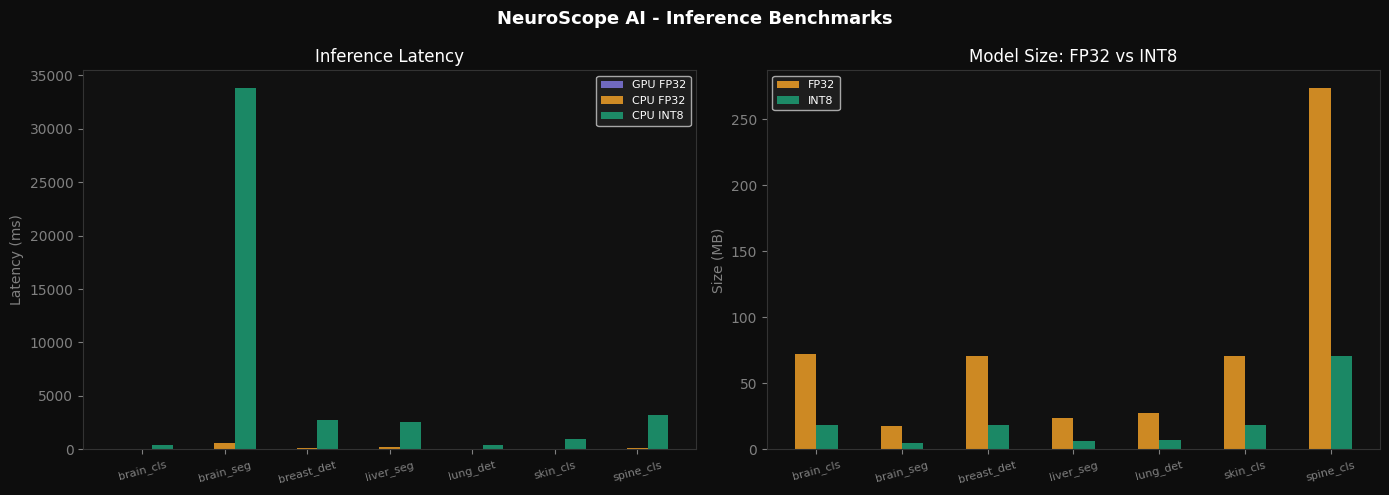

Benchmark chart saved


In [15]:
import os, numpy as np
import matplotlib.pyplot as plt

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb10_quantization')

if not results:
    print('No results -- run Cells 4 and 6 first')
else:
    model_names = [m['name'] for m in MODEL_REGISTRY
                   if m['name'] in results]

    gpu_times  = [results[n].get('gpu_fp32', {}).get('mean_ms') for n in model_names]
    cpu_times  = [results[n].get('cpu_fp32', {}).get('mean_ms') for n in model_names]
    int8_times = [results[n].get('cpu_int8', {}).get('mean_ms') for n in model_names]

    x     = np.arange(len(model_names))
    width = 0.25

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
    fig.suptitle('NeuroScope AI - Inference Benchmarks',
                 color='white', fontsize=13, fontweight='bold')

    # Latency comparison
    ax = axes[0]
    if any(t for t in gpu_times if t):
        gpu_vals = [t if t else 0 for t in gpu_times]
        ax.bar(x - width, gpu_vals,  width, label='GPU FP32',  color='#7F77DD', alpha=0.85)
    cpu_vals  = [t if t else 0 for t in cpu_times]
    int8_vals = [t if t else 0 for t in int8_times]
    ax.bar(x,         cpu_vals,  width, label='CPU FP32',  color='#EF9F27', alpha=0.85)
    ax.bar(x + width, int8_vals, width, label='CPU INT8',  color='#1D9E75', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, color='gray', fontsize=8)
    ax.set_ylabel('Latency (ms)', color='gray')
    ax.set_title('Inference Latency', color='white')
    ax.legend(facecolor='#222', labelcolor='white', fontsize=8)
    ax.set_facecolor('#111')
    ax.spines[:].set_color('#333')
    ax.tick_params(colors='gray')

    # Model size comparison
    ax2 = axes[1]
    QUANT = os.path.join(BASE, 'models', 'quantized')
    fp32_sizes = []
    int8_sizes = []
    for m in MODEL_REGISTRY:
        if m['name'] not in model_names:
            continue
        fp32_mb = os.path.getsize(m['path']) / (1024**2) if os.path.exists(m['path']) else 0
        qpath   = quant_paths.get(m['name'], '')
        int8_mb = os.path.getsize(qpath) / (1024**2) if qpath and os.path.exists(qpath) else 0
        fp32_sizes.append(fp32_mb)
        int8_sizes.append(int8_mb)

    ax2.bar(x - width/2, fp32_sizes, width, label='FP32', color='#EF9F27', alpha=0.85)
    ax2.bar(x + width/2, int8_sizes, width, label='INT8', color='#1D9E75', alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, rotation=15, color='gray', fontsize=8)
    ax2.set_ylabel('Size (MB)', color='gray')
    ax2.set_title('Model Size: FP32 vs INT8', color='white')
    ax2.legend(facecolor='#222', labelcolor='white', fontsize=8)
    ax2.set_facecolor('#111')
    ax2.spines[:].set_color('#333')
    ax2.tick_params(colors='gray')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'benchmark_results.png'),
                dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print('Benchmark chart saved')

---
## Cell 9 - Deployment Summary Table

In [16]:
import os, json

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb10_quantization')
QUANT = os.path.join(BASE, 'models', 'quantized')

print('=' * 80)
print('  NEUROSCOPE AI - DEPLOYMENT READINESS TABLE')
print('=' * 80)
print(f'{"Model":15s} {"FP32 MB":8s} {"INT8 MB":8s} {"Ratio":7s} '
      f'{"GPU ms":8s} {"CPU FP32":10s} {"CPU INT8":10s} {"Tier"}')
print('-' * 80)

summary = []
for m in MODEL_REGISTRY:
    name = m['name']
    if not os.path.exists(m['path']):
        continue

    fp32_mb = os.path.getsize(m['path']) / (1024**2)
    qpath   = quant_paths.get(name, '')
    int8_mb = os.path.getsize(qpath) / (1024**2) if qpath and os.path.exists(qpath) else 0
    ratio   = fp32_mb / int8_mb if int8_mb > 0 else 0

    gpu_ms  = results.get(name, {}).get('gpu_fp32',  {}).get('mean_ms', 0)
    cpu_ms  = results.get(name, {}).get('cpu_fp32',  {}).get('mean_ms', 0)
    int8_ms = results.get(name, {}).get('cpu_int8',  {}).get('mean_ms', 0)

    # Tier assessment
    if int8_ms > 0 and int8_ms < 500:
        tier = 'T1+T2+T3'
    elif int8_ms > 0 and int8_ms < 2000:
        tier = 'T1+T2'
    else:
        tier = 'T1 only'

    gpu_s  = f'{gpu_ms:.0f}ms'  if gpu_ms  else 'N/A'
    cpu_s  = f'{cpu_ms:.0f}ms'  if cpu_ms  else 'N/A'
    int8_s = f'{int8_ms:.0f}ms' if int8_ms else 'N/A'
    rat_s  = f'{ratio:.1f}x'    if ratio   else 'N/A'

    print(f'{name:15s} {fp32_mb:8.1f} {int8_mb:8.1f} {rat_s:7s} '
          f'{gpu_s:8s} {cpu_s:10s} {int8_s:10s} {tier}')

    summary.append({
        'model': name, 'pipeline': m['pipeline'],
        'fp32_mb': round(fp32_mb, 1), 'int8_mb': round(int8_mb, 1),
        'ratio': round(ratio, 1),
        'gpu_ms': round(gpu_ms, 1), 'cpu_fp32_ms': round(cpu_ms, 1),
        'cpu_int8_ms': round(int8_ms, 1), 'tier': tier,
    })

print('=' * 80)
print()
print('Tier definitions:')
print('  T1 : GPU server    -- FP32/FP16 full precision')
print('  T2 : CPU workstation -- INT8 quantized')
print('  T3 : Edge/offline  -- INT8 + rule-based fallback')

# Save summary JSON
summary_path = os.path.join(OUT, 'deployment_summary.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
print(f'\nSummary saved: {summary_path}')

  NEUROSCOPE AI - DEPLOYMENT READINESS TABLE
Model           FP32 MB  INT8 MB  Ratio   GPU ms   CPU FP32   CPU INT8   Tier
--------------------------------------------------------------------------------
brain_cls           72.0     18.8 3.8x    11ms     19ms       411ms      T1+T2+T3
brain_seg           18.0      4.6 3.9x    52ms     579ms      33768ms    T1 only
breast_det          70.7     18.5 3.8x    20ms     112ms      2736ms     T1 only
liver_seg           24.1      6.2 3.9x    11ms     180ms      2596ms     T1 only
lung_det            27.3      6.9 4.0x    6ms      10ms       431ms      T1+T2+T3
skin_cls            71.0     18.5 3.8x    15ms     43ms       986ms      T1+T2
spine_cls          273.2     70.8 3.9x    36ms     133ms      3218ms     T1 only

Tier definitions:
  T1 : GPU server    -- FP32/FP16 full precision
  T2 : CPU workstation -- INT8 quantized
  T3 : Edge/offline  -- INT8 + rule-based fallback

Summary saved: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\o

---
## Cell 10 - Summary

In [17]:
import os

BASE  = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
QUANT = os.path.join(BASE, 'models', 'quantized')
OUT   = os.path.join(BASE, 'outputs', 'nb10_quantization')

print('=' * 65)
print('  NOTEBOOK 10 - ONNX EXPORT & QUANTIZATION')
print('=' * 65)
print()

# Count quantized models
n_quant = sum(
    1 for path in quant_paths.values()
    if path and os.path.exists(path)
) if 'quant_paths' in dir() else 0

print(f'  Models quantized : {n_quant}/{len(MODEL_REGISTRY)}')
print(f'  Quantized dir    : {QUANT}')
print(f'  Benchmark chart  : {os.path.join(OUT, "benchmark_results.png")}')
print(f'  Deployment table : {os.path.join(OUT, "deployment_summary.json")}')
print()
print('  Quantization method : Dynamic INT8 (weight quantization)')
print('  No calibration data required')
print('  Expected accuracy loss : <1% for classification models')
print()
print('  Deployment tiers covered:')
print('    Tier 1 GPU  : FP32 ONNX (all models)')
print('    Tier 2 CPU  : INT8 ONNX (all models)')
print('    Tier 3 Edge : INT8 ONNX + rule-based treatment fallback')
print()
print('  Next: 11_Agent_Orchestrator.ipynb')
print('    - All 11 agents as Python classes')
print('    - Pipeline coordinator with conditional branching')
print('    - WebSocket streaming')
print('    - Claude API integration (Agent 5)')
print('    - Rule-based fallback for offline mode')
print('=' * 65)

  NOTEBOOK 10 - ONNX EXPORT & QUANTIZATION

  Models quantized : 7/7
  Quantized dir    : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\quantized
  Benchmark chart  : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\outputs\nb10_quantization\benchmark_results.png
  Deployment table : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\outputs\nb10_quantization\deployment_summary.json

  Quantization method : Dynamic INT8 (weight quantization)
  No calibration data required
  Expected accuracy loss : <1% for classification models

  Deployment tiers covered:
    Tier 1 GPU  : FP32 ONNX (all models)
    Tier 2 CPU  : INT8 ONNX (all models)
    Tier 3 Edge : INT8 ONNX + rule-based treatment fallback

  Next: 11_Agent_Orchestrator.ipynb
    - All 11 agents as Python classes
    - Pipeline coordinator with conditional branching
    - WebSocket streaming
    - Claude API integration (Agent 5)
    - Rule-based fallback for offline mode
